
# Renewal Process: Light Bulb Replacement in a Library Corridor

## Real-life scenario

A library corridor uses a single bulb. Whenever the bulb burns out, the maintenance staff immediately replaces it with a new bulb of the same type.

Let $X_1, X_2, X_3, \dots$ denote the lifetimes of successive bulbs, measured in days. We assume that:

- the lifetimes are independent,
- they all have the same distribution,
- each replacement makes the system start afresh.

This is a natural example of a **renewal process**.

## Model

The interarrival times are the bulb lifetimes:

$$
X_1, X_2, X_3, \dots
$$

The renewal times are

$$
S_n = X_1 + X_2 + \cdots + X_n.
$$

Here, $S_n$ is the day on which the $n$-th replacement occurs.

The renewal counting process is

$$
N(t) = \max\{n \geq 0 : S_n \leq t\}.
$$

So $N(t)$ counts how many replacements have happened by day $t$.

## Chosen lifetime distribution

In this notebook we use the following simple discrete model for the bulb lifetime $X$:

- $1$ day with probability $0.10$
- $2$ days with probability $0.20$
- $3$ days with probability $0.35$
- $4$ days with probability $0.20$
- $5$ days with probability $0.15$

This is a genuine renewal-process model because the lifetimes are i.i.d., but they are **not** exponential. So this is not just a Poisson process in disguise.

## Main theoretical quantities

The mean lifetime is

$$
\mu = \mathbb{E}[X].
$$

The long-run renewal rate is

$$
\frac{1}{\mu}.
$$

For large $t$, renewal theory tells us that

$$
N(t) \approx \frac{t}{\mu},
\qquad
\mathbb{E}[N(t)] \approx \frac{t}{\mu}.
$$

So the average number of replacements by day $t$ is approximately $t$ divided by the mean bulb lifetime.

## What this notebook does

This notebook is organized in a coherent step-by-step way:

1. load the CSV files provided with the notebook,
2. display the loaded data in separate cells,
3. compute the theoretical quantities from the lifetime distribution,
4. simulate many sample paths of the renewal process,
5. compare simulation with the long-run renewal approximation,
6. visualize the results.

All code uses the same CSV files placed in the same folder as this notebook.



## CSV files used in this notebook

This notebook expects the following files in the same folder:

- `renewal_interarrival_distribution.csv`
- `renewal_analytical_long_run.csv`
- `renewal_simulation_summary.csv`
- `renewal_sample_paths.csv`
- `renewal_key_results_summary.csv`
- `renewal_sample_arrival_times.csv`

The next cell imports the required libraries.


In [2]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



## Load the CSV files

In this cell, we load all the CSV files from the current working directory.  
This loading step is intentionally separate from the display step.


In [4]:
import os
DATA_DIR = "."
print(os.listdir(DATA_DIR))

dist_df = pd.read_csv(os.path.join(DATA_DIR, "renewal_interarrival_distribution.csv"))
analyical_df = pd.read_csv(os.path.join(DATA_DIR, "renewal_analytical_long_run.csv"))
simulation_df = pd.read_csv(os.path.join(DATA_DIR, "renewal_simulation_summary.csv"))
sample_paths_df = pd.read_csv(os.path.join(DATA_DIR, "renewal_sample_paths.csv"))
key_results_df = pd.read_csv(os.path.join(DATA_DIR, "renewal_key_results_summary.csv"))
arrival_example_df = pd.read_csv(os.path.join(DATA_DIR, "renewal_sample_arrival_times.csv"))

['renewal_key_results_summary.csv', 'renewal_process_light_bulb_explainer.ipynb', 'renewal_analytical_long_run.csv', 'renewal_sample_arrival_times.csv', 'renewal_interarrival_distribution.csv', 'renewal_simulation_summary.csv', 'renewal_sample_paths.csv', '.ipynb_checkpoints']



## Display the loaded data

This cell only displays the CSV data that was loaded in the previous cell.


In [5]:
print("Interarrival distribution:")
display(dist_df)

print("Analytical long-run approximation:")
display(analyical_df.head(10))

print("Simulation summary:")
display(simulation_df.head(10))

print("Five sample paths:")
display(sample_paths_df.head(10))

print("Key results summary:")
display(key_results_df)

print("Sample arrival times from one path:")
display(arrival_example_df.head(10))

Interarrival distribution:


,lifetime_days,probability,contribution_to_mean
0,1,0.10,0.10
1,2,0.20,0.40
2,3,0.35,1.05
3,4,0.20,0.80
4,5,0.15,0.75


Analytical long-run approximation:


,day_t,approx_expected_renewals_t_over_mean,long_run_renewal_rate_1_over_mean
0,0,0.000000,0.322581
1,1,0.322581,0.322581
2,2,0.645161,0.322581
3,3,0.967742,0.322581
4,4,1.290323,0.322581
5,5,1.612903,0.322581
6,6,1.935484,0.322581
7,7,2.258065,0.322581
8,8,2.580645,0.322581
9,9,2.903226,0.322581


Simulation summary:


...

,day_t,path_1_N_t,path_2_N_t,path_3_N_t,path_4_N_t,path_5_N_t
0,0,0,0,0,0,0
1,1,0,0,0,0,1
2,2,0,0,1,0,1
3,3,0,1,1,0,1
4,4,1,1,2,0,2
5,5,2,2,2,1,2
6,6,2,2,2,1,3
7,7,3,2,3,2,3
8,8,3,2,3,2,3
9,9,4,3,3,2,3


Key results summary:


,quantity,value
0,Mean lifetime E[X],3.100000
1,Variance of lifetime Var(X),1.390000
2,Long-run renewal rate 1/E[X],0.322581
3,Approximate E[N(10)],3.225806
4,Approximate E[N(20)],6.451613
5,Approximate E[N(30)],9.677419
6,Simulated average N(10),2.954900
7,Simulated average N(20),6.184000
8,Simulated average N(30),9.421600


Sample arrival times from one path:


,renewal_number,interarrival_days,arrival_day
0,1,4,4
1,2,1,5
2,3,2,7
3,4,2,9
4,5,2,11
5,6,4,15
6,7,5,20
7,8,2,22
8,9,4,26



## Build the renewal-process model from the loaded data

Let the possible bulb lifetimes be denoted by values in the first column of the distribution table, and their probabilities by the second column.

If $X$ is one bulb lifetime, then

$$
\mu = \mathbb{E}[X] = \sum_x x \, \mathbb{P}(X=x),
$$

and

$$
\mathrm{Var}(X) = \sum_x (x-\mu)^2 \, \mathbb{P}(X=x).
$$

The long-run renewal rate is

$$
\frac{1}{\mu}.
$$

The next cell extracts the lifetime distribution directly from the CSV and computes these quantities.


In [6]:

lifetimes = dist_df["lifetime_days"].to_numpy(dtype=int)
probs = dist_df["probability"].to_numpy(dtype=float)

mu = np.sum(lifetimes * probs)
var = np.sum(((lifetimes - mu) ** 2) * probs)
renewal_rate = 1 / mu

print(f"Mean lifetime E[X] = {mu:.4f} days")
print(f"Variance Var(X) = {var:.4f}")
print(f"Long-run renewal rate 1/E[X] = {renewal_rate:.6f} renewals per day")


Mean lifetime E[X] = 3.1000 days
Variance Var(X) = 1.3900
Long-run renewal rate 1/E[X] = 0.322581 renewals per day



## Define the renewal-process simulation code

A renewal process is built from successive interarrival times:

$$
S_n = X_1 + X_2 + \cdots + X_n,
$$

and

$$
N(t) = \max\{n \geq 0 : S_n \leq t\}.
$$

The following cell defines:

- a function to simulate one list of renewal times up to day $T$,
- a function to convert renewal times into the counting process $N(t)$,
- a function to simulate many independent sample paths.


In [7]:

def simulate_arrival_times_until(T, lifetimes, probs, rng):
    t = 0
    interarrivals = []
    arrivals = []

    while True:
        x = int(rng.choice(lifetimes, p=probs))
        if t + x > T:
            break
        t += x
        interarrivals.append(x)
        arrivals.append(t)

    return interarrivals, arrivals


def count_path_from_arrivals(arrivals, T):
    counts = []
    j = 0
    for t in range(T + 1):
        while j < len(arrivals) and arrivals[j] <= t:
            j += 1
        counts.append(j)
    return counts


def simulate_many_renewal_paths(runs, T, lifetimes, probs, seed=123):
    rng = np.random.default_rng(seed)
    paths = np.zeros((runs, T + 1), dtype=int)
    interarrival_lists = []
    arrival_lists = []

    for r in range(runs):
        interarrivals, arrivals = simulate_arrival_times_until(T, lifetimes, probs, rng)
        interarrival_lists.append(interarrivals)
        arrival_lists.append(arrivals)
        paths[r, :] = count_path_from_arrivals(arrivals, T)

    average_counts = paths.mean(axis=0)
    probability_at_least_one = (paths >= 1).mean(axis=0)
    probability_at_least_five = (paths >= 5).mean(axis=0)

    return paths, average_counts, probability_at_least_one, probability_at_least_five, interarrival_lists, arrival_lists



## Reproduce the main numerical results

We now simulate the process for $30$ days and compare:

- simulated average renewals,
- the long-run approximation $t / \mu$,
- probabilities of observing at least one or at least five renewals by day $t$.


In [8]:

T = 30
runs = 10000
times = np.arange(T + 1)

paths, avg_counts, prob_at_least_one, prob_at_least_five, interarrival_lists, arrival_lists = simulate_many_renewal_paths(
    runs=runs,
    T=T,
    lifetimes=lifetimes,
    probs=probs,
    seed=123
)

reproduced_summary_df = pd.DataFrame({
    "day_t": times,
    "approx_expected_renewals_t_over_mean": times / mu,
    "simulated_average_renewals": avg_counts,
    "simulated_probability_at_least_1_renewal": prob_at_least_one,
    "simulated_probability_at_least_5_renewals": prob_at_least_five,
})

display(reproduced_summary_df.head(12))


,day_t,approx_expected_renewals_t_over_mean,simulated_average_renewals,simulated_probability_at_least_1_renewal,simulated_probability_at_least_5_renewals
0,0,0.000000,0.0000,0.0000,0.0000
1,1,0.322581,0.1005,0.1005,0.0000
2,2,0.645161,0.3057,0.2961,0.0000
3,3,0.967742,0.7018,0.6501,0.0000
4,4,1.290323,1.0165,0.8502,0.0000
5,5,1.612903,1.3651,1.0000,0.0000
6,6,1.935484,1.6563,1.0000,0.0002
7,7,2.258065,1.9719,1.0000,0.0005
8,8,2.580645,2.3124,1.0000,0.0017
9,9,2.903226,2.6318,1.0000,0.0083



## Compare the provided CSV summaries with the reproduced computations

The next cell checks the main numbers at a few time points.


In [9]:

check_df = pd.DataFrame({
    "day_t": [10, 20, 30],
    "csv_simulated_average": simulation_df.loc[simulation_df["day_t"].isin([10, 20, 30]), "simulated_average_renewals"].to_numpy(),
    "reproduced_simulated_average": reproduced_summary_df.loc[reproduced_summary_df["day_t"].isin([10, 20, 30]), "simulated_average_renewals"].to_numpy(),
    "long_run_approximation": reproduced_summary_df.loc[reproduced_summary_df["day_t"].isin([10, 20, 30]), "approx_expected_renewals_t_over_mean"].to_numpy()
})

display(check_df)


,day_t,csv_simulated_average,reproduced_simulated_average,long_run_approximation
0,10,2.9549,2.9549,3.225806
1,20,6.1840,6.1840,6.451613
2,30,9.4216,9.4216,9.677419



## Plot the renewal-process results

We plot:

- the simulated average number of renewals by day $t$,
- the long-run approximation $t / \mu$.

We also plot a few sample paths of the counting process $N(t)$.


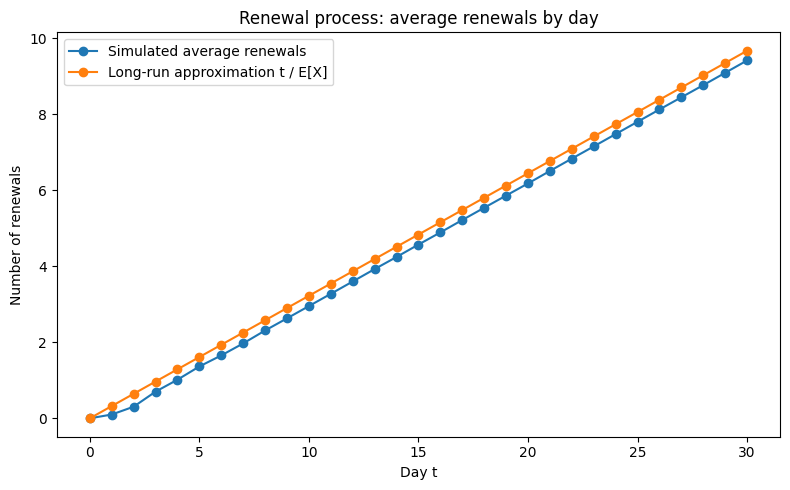

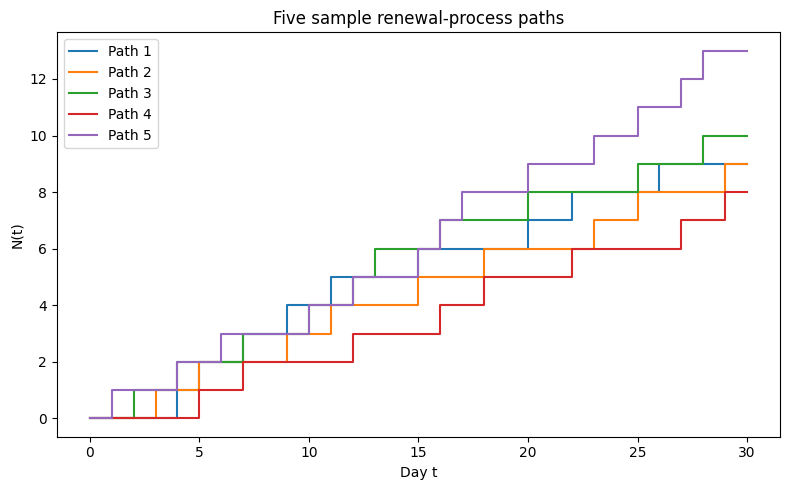

In [10]:

plt.figure(figsize=(8, 5))
plt.plot(times, avg_counts, marker="o", label="Simulated average renewals")
plt.plot(times, times / mu, marker="o", label="Long-run approximation t / E[X]")
plt.xlabel("Day t")
plt.ylabel("Number of renewals")
plt.title("Renewal process: average renewals by day")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for i in range(5):
    plt.step(times, paths[i], where="post", label=f"Path {i+1}")
plt.xlabel("Day t")
plt.ylabel("N(t)")
plt.title("Five sample renewal-process paths")
plt.legend()
plt.tight_layout()
plt.show()



## Interpretation

This model says:

- each bulb lifetime is one interarrival time,
- each replacement is a renewal,
- $N(t)$ counts the number of replacements by day $t$.

For this example, the mean lifetime is approximately

$$
\mu \approx 3.1 \text{ days}.
$$

So the long-run renewal rate is approximately

$$
\frac{1}{\mu} \approx 0.3226 \text{ renewals per day}.
$$

Hence,

$$
\mathbb{E}[N(30)] \approx \frac{30}{3.1} \approx 9.68.
$$

The simulation gives a value close to this, which is exactly what renewal theory suggests.

## Final conclusion

A renewal process is a natural model for repeated replacement systems.  
The bulb example is easy to understand because every failure restarts the same random experiment again.

Mathematically, that is why the sequence of lifetimes creates renewal times

$$
S_n = X_1 + \cdots + X_n
$$

and a counting process

$$
N(t) = \max\{n \geq 0 : S_n \leq t\}.
$$

This notebook combines the theory, the data, and the simulation in one coherent explanatory workflow.
